In [34]:
# Here we load standard packages to read data and plot it
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Now we will read the provided files

In the cell below, we read the file (`Dataset_1.txt` and `Dataset_2.txt`) and load the data into the variables required for the analysis:

- **time** — timestamp
- **Hs** — significant wave height
- **Tp** — peak wave period
- **Dir** — mean wave direction

In [35]:
# Read wave data file
filename = "Dataset_1.txt"   
A = np.loadtxt(filename, skiprows=2) # Read numeric matrix skipping first 2 header lines

# Load wave data into our variables
# Replace missing values (-9999.9)
A[A == -9999.9] = np.nan
# Build datetime from columns: YYYY MM DD HH
time = pd.to_datetime(
    dict(year=A[:,0].astype(int),
         month=A[:,1].astype(int),
         day=A[:,2].astype(int),
         hour=A[:,3].astype(int))
)

# Extract main wave parameters 
Hs  = A[:,4]    # Significant wave height (m)
Tp  = A[:,8]    # Peak period (s)
Dir = A[:,12]   # Mean wave direction (FROM, deg), 0=N,90=E

# Producing the first plot

Below, we will visualize the variables using time-series plots. This will allow us to identify energetic periods and begin characterizing the wave climate.

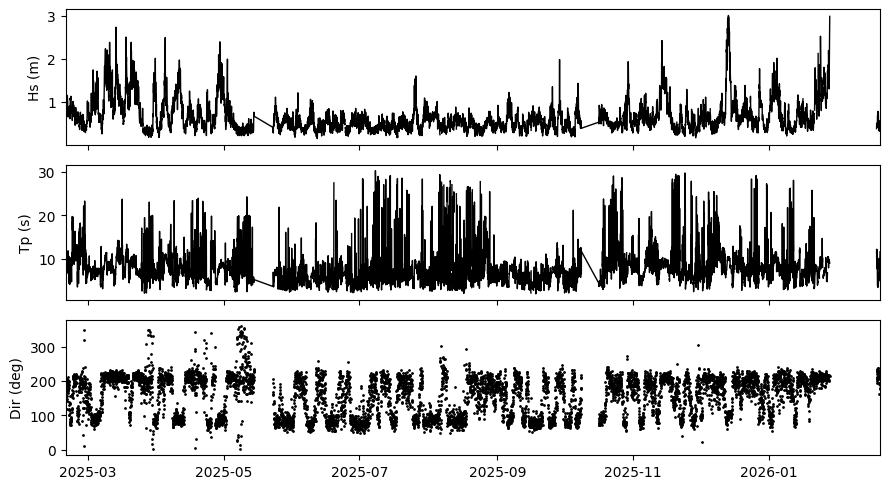

In [40]:
# -------------------- OUR FIRST PLOT!!!! --------------------
fig, axes = plt.subplots(3, 1, figsize=(9, 5), sharex=True)
axes[0].plot(time, Hs, 'k', lw=1)
axes[0].set_ylabel("Hs (m)")
axes[1].plot(time, Tp, 'k', lw=1)
axes[1].set_ylabel("Tp (s)")
axes[2].plot(time, Dir, 'k.', ms=2)
axes[2].set_ylabel("Dir (deg)")
axes[2].set_xlim(time.iloc[0], time.iloc[-1])
for ax in axes:
    ax.tick_params(labelsize=10)
plt.tight_layout()

# Wave Rose

In this section, we will generate a wave rose — a specialized diagram that illustrates the distribution of wave direction and wave energy (or wave height). This type of plot helps us understand the dominant wave directions and the relative importance of different sea states.

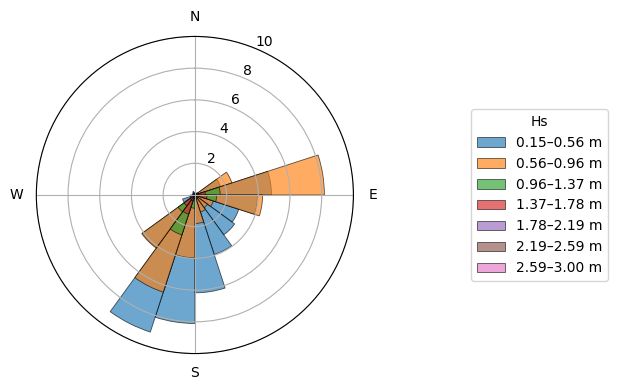

In [37]:
# -------------------- WAVE ROSE --------------------
ok = np.isfinite(Hs) & np.isfinite(Dir)
heights = Hs[ok]
dirs    = np.mod(Dir[ok], 360.0)  

# Try modifying these parameters and seewhat happens!
xn = 7    
yn = 20

# ------------------Plot
Yedges = np.linspace(0, 360, yn+1)
Xedges = np.linspace(np.nanmin(heights), np.nanmax(heights), xn+1)
N, xedges, yedges = np.histogram2d(heights, dirs, bins=[Xedges, Yedges])
probs = N / np.nansum(N) * 100.0  # % occurrence
fig = plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='polar')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
theta_edges = np.deg2rad(Yedges)
theta_centers = (theta_edges[:-1] + theta_edges[1:]) / 2
width = np.diff(theta_edges)
handles = []
for i in range(probs.shape[0]):  # each Hs bin
    bars = ax.bar(theta_centers, probs[i, :], width=width, align='center',
                  alpha=0.65, edgecolor='k', linewidth=0.6)
    handles.append(bars[0])

ax.set_thetagrids([0, 90, 180, 270], labels=['N','E','S','W'])
ax.set_rlabel_position(22.5)
ax.set_ylim(0, max(5, np.nanmax(probs)*1.1))
labels = [f"{Xedges[i]:.2f}–{Xedges[i+1]:.2f} m" for i in range(xn)]
ax.legend(handles, labels, title="Hs",
          loc='center left',
          bbox_to_anchor=(1.35, 0.5),
          frameon=True)
plt.tight_layout()
plt.show()